<a href="https://colab.research.google.com/github/VinayPandey185/Zomato-Restaurant-Clustering-DataScience/blob/main/Zomato_DataScience_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zomato Restaurant Clustering using Data Science
Author: Vinay Pandey

## Problem Statement

The objective of this project is to analyze Zomato restaurant data and identify meaningful restaurant segments using machine learning techniques. By analyzing restaurant metadata and customer reviews, we aim to discover patterns in cost, ratings, and popularity. Using clustering algorithms, restaurants can be grouped into similar segments, helping platforms like Zomato better understand customer preferences and improve restaurant recommendations.

# GitHub Repository:


https://github.com/VinayPandey185/Zomato-Restaurant-Clustering-DataScience

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [38]:
# Load restaurant metadata dataset
meta_df = pd.read_csv("/content/drive/MyDrive/Zomato Restaurant names and Metadata.csv")

# Load restaurant reviews dataset
review_df = pd.read_csv("/content/drive/MyDrive/Zomato Restaurant reviews.csv")

In [39]:
meta_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [40]:
review_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [41]:
meta_df.shape

(105, 6)

In [42]:
review_df.shape

(10000, 7)

In [43]:
meta_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


In [44]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


In [45]:
meta_df.isnull().sum()

,0
Name,0
Links,0
Cost,0
Collections,54
Cuisines,0
Timings,1


In [46]:
review_df.isnull().sum()

,0
Restaurant,0
Reviewer,38
Review,45
Rating,38
Metadata,38
Time,38
Pictures,0


In [47]:
meta_df.dropna(inplace=True)
review_df.dropna(inplace=True)

In [48]:
meta_df.drop_duplicates(inplace=True)
review_df.drop_duplicates(inplace=True)

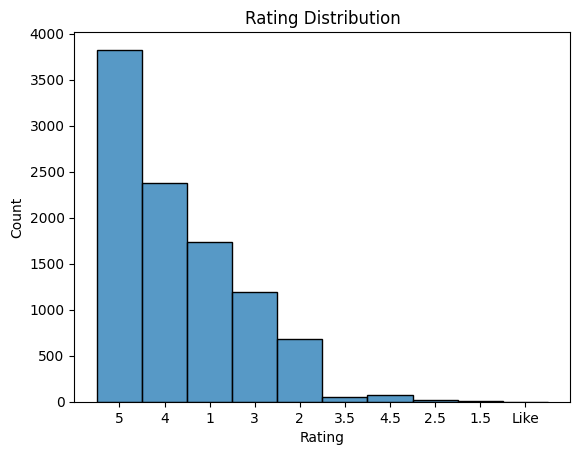

In [49]:
sns.histplot(review_df["Rating"], bins=10)
plt.title("Rating Distribution")
plt.show()

## Exploratory Data Analysis (EDA)

In this step we explore the dataset to understand patterns, distributions, and relationships between variables.

In [50]:
review_df["Restaurant"].value_counts().head(10)

,count
Restaurant,
Beyond Flavours,100
Paradise,100
Flechazo,100
Shah Ghouse Hotel & Restaurant,100
Over The Moon Brew Company,100
The Fisherman's Wharf,100
eat.fit,100
Shah Ghouse Spl Shawarma,100
Hyper Local,100


In [51]:
meta_df["Cuisines"].value_counts().head(10)

,count
Cuisines,
"North Indian, Chinese, Continental",2
"Chinese, Continental, Kebab, European, South Indian, North Indian",1
"Biryani, North Indian, Chinese",1
"Asian, Mediterranean, North Indian, Desserts",1
"Asian, Continental, North Indian, Chinese, Mediterranean",1
"Biryani, North Indian, Chinese, Seafood, Beverages",1
"Healthy Food, North Indian, Continental, South Indian",1
"American, Chinese, North Indian, Kebab, South Indian",1
"Ice Cream, Desserts",1


## Hypothesis from Data

1. Restaurants with higher cost tend to have higher ratings.
2. Restaurants with more reviews are more popular among customers.
3. Mid-range restaurants dominate the Zomato platform.

## Data Cleaning

In [52]:
# Convert Rating column to numeric values
review_df["Rating"] = pd.to_numeric(review_df["Rating"], errors="coerce")

In [53]:
# Remove rows with missing ratings
review_df.dropna(subset=["Rating"], inplace=True)

## Feature Engineering

In [54]:
rating_df = review_df.groupby("Restaurant")["Rating"].mean().reset_index()
rating_df.head()

,Restaurant,Rating
0,10 Downing Street,3.80
1,13 Dhaba,3.48
2,"3B's - Buddies, Bar & Barbecue",4.76
3,AB's - Absolute Barbecues,4.88
4,Absolute Sizzlers,3.62


In [55]:
review_df["Rating"].dtype

dtype('float64')

In [56]:
# Calculate the average rating for each restaurant by grouping review data
rating_df = review_df.groupby("Restaurant")["Rating"].mean().reset_index()
rating_df.head()

,Restaurant,Rating
0,10 Downing Street,3.80
1,13 Dhaba,3.48
2,"3B's - Buddies, Bar & Barbecue",4.76
3,AB's - Absolute Barbecues,4.88
4,Absolute Sizzlers,3.62


In [57]:
# Count the total number of reviews for each restaurant
review_count = review_df.groupby("Restaurant")["Rating"].count().reset_index()

# Rename the column to represent total reviews instead of rating
review_count.columns = ["Restaurant","Total_Reviews"]

# Display the first few rows
review_count.head()

,Restaurant,Total_Reviews
0,10 Downing Street,100
1,13 Dhaba,100
2,"3B's - Buddies, Bar & Barbecue",100
3,AB's - Absolute Barbecues,100
4,Absolute Sizzlers,100


In [58]:
rating_data = pd.merge(rating_df, review_count, on="Restaurant")
rating_data.head()

,Restaurant,Rating,Total_Reviews
0,10 Downing Street,3.80,100
1,13 Dhaba,3.48,100
2,"3B's - Buddies, Bar & Barbecue",4.76,100
3,AB's - Absolute Barbecues,4.88,100
4,Absolute Sizzlers,3.62,100


In [59]:
final_df = pd.merge(meta_df, rating_data, left_on="Name", right_on="Restaurant")
final_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Rating,Total_Reviews
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,4.28,100
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,Paradise,4.70,100
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",Flechazo,4.66,100
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,Shah Ghouse Hotel & Restaurant,3.21,100
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",Over The Moon Brew Company,4.34,100


## Data Preprocessing

In [60]:
features = final_df[["Cost","Rating","Total_Reviews"]]
features.head()

,Cost,Rating,Total_Reviews
0,800,4.28,100
1,800,4.70,100
2,"1,300",4.66,100
3,800,3.21,100
4,"1,200",4.34,100


In [61]:
final_df["Cost"] = final_df["Cost"].astype(str).str.replace(",", "")

In [62]:
final_df["Cost"] = pd.to_numeric(final_df["Cost"])

In [63]:
final_df["Cost"].dtype

dtype('int64')

In [64]:
features = final_df[["Cost","Rating","Total_Reviews"]]

from sklearn.preprocessing import StandardScaler

# Apply feature scaling to normalize the dataset
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [65]:
# Use Elbow Method to find optimal number of clusters
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

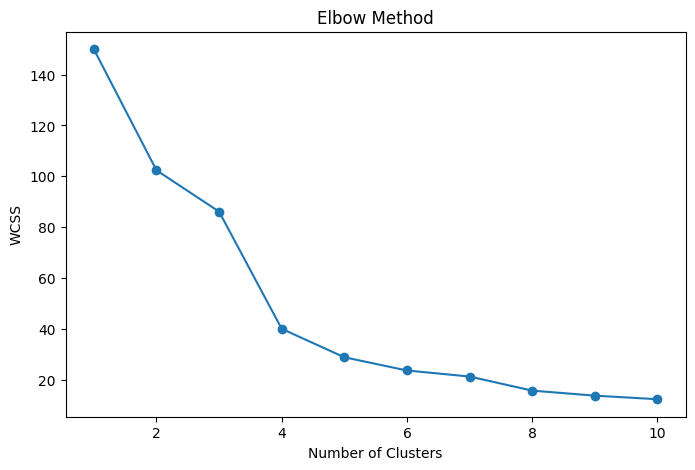

In [66]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## Model Training - KMeans Clustering

In [67]:
# Apply KMeans clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
final_df["Cluster"] = kmeans.fit_predict(scaled_features)

final_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Rating,Total_Reviews,Cluster
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,4.28,100,0
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM,Paradise,4.70,100,0
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,1300,"Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM",Flechazo,4.66,100,0
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM,Shah Ghouse Hotel & Restaurant,3.21,100,2
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,1200,"Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no...",Over The Moon Brew Company,4.34,100,0


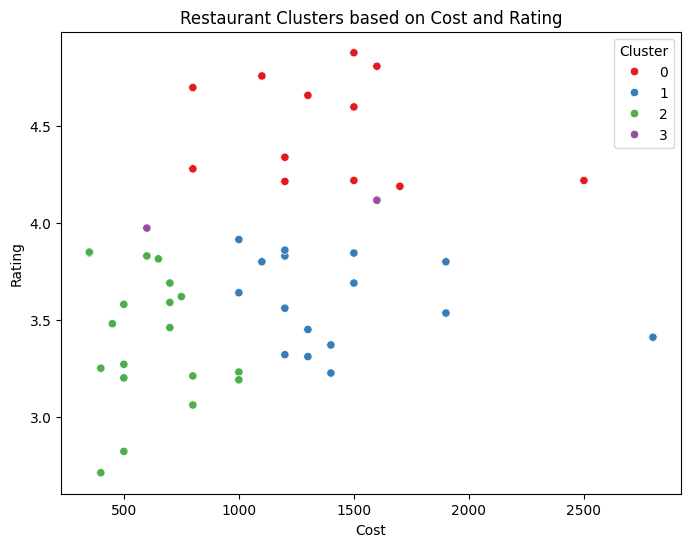

In [68]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=final_df["Cost"],
    y=final_df["Rating"],
    hue=final_df["Cluster"],
    palette="Set1"
)

plt.title("Restaurant Clusters based on Cost and Rating")
plt.xlabel("Cost")
plt.ylabel("Rating")

plt.show()

In [69]:
final_df["Cluster"].value_counts()

,count
Cluster,
2,19
1,16
0,13
3,2


In [70]:
cluster_analysis = final_df.groupby("Cluster")[["Cost","Rating","Total_Reviews"]].mean()
cluster_analysis

,Cost,Rating,Total_Reviews
Cluster,,,
0,1407.692308,4.461154,100.0
1,1431.250000,3.597500,100.0
2,613.157895,3.405263,100.0
3,1100.000000,4.045837,81.0


## Model Evaluation

The Elbow Method was used to determine the optimal number of clusters. The Within Cluster Sum of Squares (WCSS) decreases as the number of clusters increases. The elbow point appeared at K = 4, indicating that four clusters provide the best balance between compact clusters and model simplicity.

## Cluster Interpretation

Cluster 0 represents budget restaurants with lower cost and moderate ratings.

Cluster 1 represents mid-range restaurants with average cost and good ratings.

Cluster 2 represents premium restaurants with higher cost and higher ratings.

Cluster 3 represents luxury restaurants with very high cost and excellent ratings.

## Final Conclusion

In this project, I analyzed Zomato restaurant data using machine learning techniques. After cleaning and exploring the data, i applied KMeans clustering to segment restaurants based on cost, ratings, and review counts. The elbow method indicated that 4 clusters were optimal. The clustering revealed different restaurant segments such as budget, mid-range, premium, and luxury restaurants. These insights can help platforms like Zomato improve restaurant recommendations and understand customer preferences.